## 1. Boilerplate

In [1]:
import sys, logging, warnings
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna

from src.models.tree_expert import TreeExpert
from src.features.pipeline import build_features_for_split
from src.evaluation.metrics import (
    compute_all_metrics,
    compute_round_breakdown,
    compute_expert_agreement,
    compute_logloss,
)
from src.config import (
    EXPERT_TYPES,
    XGBOOST_PARAMS,
    OPTUNA_SEARCH_SPACE,
    OPTUNA_N_TRIALS,
    FIRST_YEAR,
    LAST_YEAR,
    SKIP_YEARS,
    EFFICIENCY_WEIGHT_FLOOR,
    UNCERTAINTY_SAME_SEED_WEIGHT,
)

sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Setup complete.")

Setup complete.


## 2. Data Split

In [2]:
all_seasons = [y for y in range(FIRST_YEAR, LAST_YEAR + 1) if y not in SKIP_YEARS]
test_seasons = [2024, 2025]
train_seasons = [y for y in all_seasons if y not in test_seasons]

train_fs, test_fs = build_features_for_split(train_seasons, test_seasons)

print(f"Train: X={train_fs.X.shape}, y={train_fs.y.shape}, seasons={train_seasons[0]}-{train_seasons[-1]}")
print(f"Test:  X={test_fs.X.shape},  y={test_fs.y.shape},  seasons={test_seasons}")
print(f"Features: {train_fs.feature_names[:10]} ... ({len(train_fs.feature_names)} total)")
print(f"Class balance (train): {train_fs.y.mean():.3f}")
print(f"Class balance (test):  {test_fs.y.mean():.3f}")

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:Loading pomeroy ratings from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/cache/kenpom_pomeroy_ratings.parquet
INFO:src.data.kaggle_loader:Loaded pomeroy ratings: 8679 rows, 25 seasons
INFO:src.data.kaggle_loader:Pomeroy merge: 7607/8315 matched. 708 unmatched (mostly non-tournament): ['Miami', 'Pennsylvania', 'Little Rock', 'McNeese', 'IU Indianapolis', 'Sam Houston', 'Missouri State', 'Louisiana', 'Miami (OH)', 'Charleston']
INFO:src.data.kaggle_loader:Final KenPom dataset: 8314 rows, 43 columns, seasons 2002–2025
INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)
INFO:src.data.merge:Merge comple

Train: X=(1262, 39), y=(1262,), seasons=2003-2023
Test:  X=(126, 39),  y=(126,),  seasons=[2024, 2025]
Features: ['adjde_delta', 'adjem_delta', 'adjoe_delta', 'adjtempo_delta', 'avg_height_delta', 'bench_delta', 'def_arate_delta', 'def_blockpct_delta', 'def_fg2pct_delta', 'def_fg3pct_delta'] ... (39 total)
Class balance (train): 0.708
Class balance (test):  0.746


## 3. Viz: Sample Weight Distributions

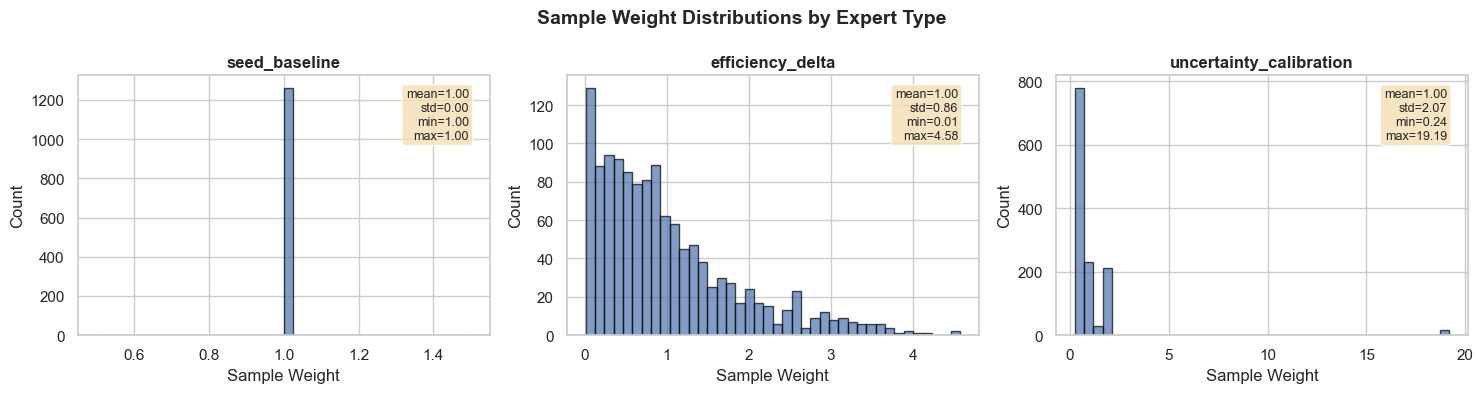

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, etype in zip(axes, EXPERT_TYPES):
    expert = TreeExpert(etype)
    weights = expert.compute_sample_weights(train_fs)
    ax.hist(weights, bins=40, edgecolor="black", alpha=0.7)
    ax.set_title(etype, fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample Weight")
    ax.set_ylabel("Count")
    stats_text = (
        f"mean={weights.mean():.2f}\n"
        f"std={weights.std():.2f}\n"
        f"min={weights.min():.2f}\n"
        f"max={weights.max():.2f}"
    )
    ax.text(
        0.95, 0.95, stats_text,
        transform=ax.transAxes, fontsize=9,
        verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

fig.suptitle("Sample Weight Distributions by Expert Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Viz: Weight vs Feature

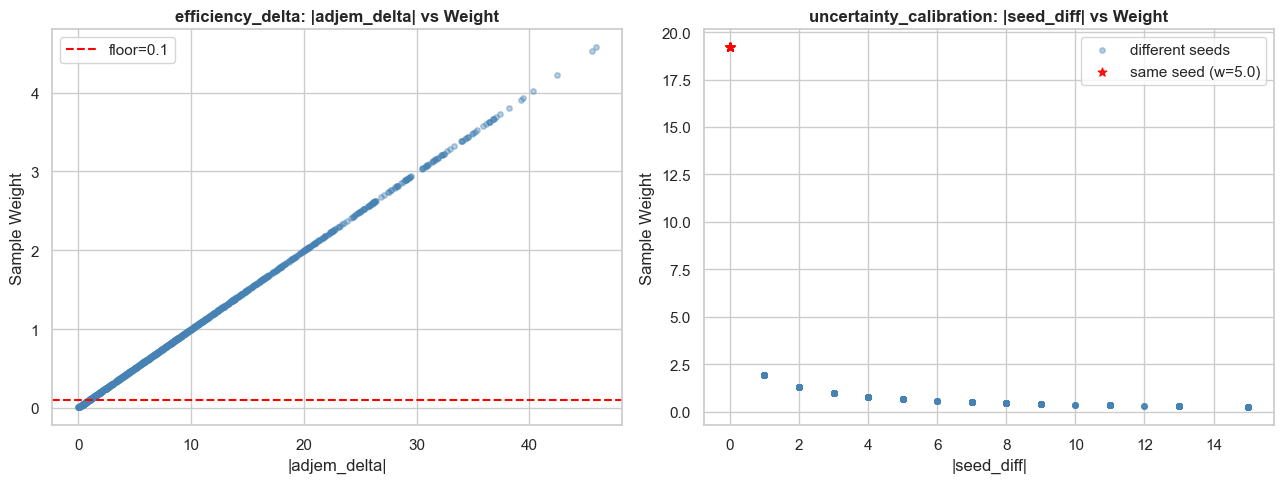

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Efficiency: |adjem_delta| vs weight
ax = axes[0]
eff_expert = TreeExpert("efficiency_delta")
eff_weights = eff_expert.compute_sample_weights(train_fs)
adjem_abs = train_fs.X["adjem_delta"].abs()
ax.scatter(adjem_abs, eff_weights, alpha=0.4, s=15, c="steelblue")
ax.set_xlabel("|adjem_delta|")
ax.set_ylabel("Sample Weight")
ax.set_title("efficiency_delta: |adjem_delta| vs Weight", fontweight="bold")
ax.axhline(y=EFFICIENCY_WEIGHT_FLOOR, color="red", linestyle="--", label=f"floor={EFFICIENCY_WEIGHT_FLOOR}")
ax.legend()

# Uncertainty: seed_diff vs weight
ax = axes[1]
unc_expert = TreeExpert("uncertainty_calibration")
unc_weights = unc_expert.compute_sample_weights(train_fs)
seed_diff = train_fs.X["seed_diff"].abs()
same_seed_mask = seed_diff == 0
ax.scatter(seed_diff[~same_seed_mask], unc_weights[~same_seed_mask], alpha=0.4, s=15, c="steelblue", label="different seeds")
ax.scatter(seed_diff[same_seed_mask], unc_weights[same_seed_mask], alpha=0.9, s=40, c="red", marker="*", label=f"same seed (w={UNCERTAINTY_SAME_SEED_WEIGHT})")
ax.set_xlabel("|seed_diff|")
ax.set_ylabel("Sample Weight")
ax.set_title("uncertainty_calibration: |seed_diff| vs Weight", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Train All 3 Experts (Default)

In [ ]:
default_experts = {}
default_metrics = {}

for etype in EXPERT_TYPES:
    expert = TreeExpert(etype)
    expert.fit(train_fs, val_fs=test_fs)
    default_experts[etype] = expert

    preds = expert.predict_proba(test_fs)
    metrics = compute_all_metrics(test_fs.y.values, preds, rounds=test_fs.meta["round"].values)
    default_metrics[etype] = metrics

    best_iter = getattr(expert.model, "best_iteration", "N/A")
    val_logloss = expert.model.evals_result()["validation_0"]["logloss"][-1]
    print(f"{etype:30s} | best_iteration={best_iter:>4} | val_logloss={val_logloss:.4f} | test_acc={metrics['accuracy']:.3f}")

print("\nDefault expert training complete.")

## 6. Viz: Learning Curves (All 3)

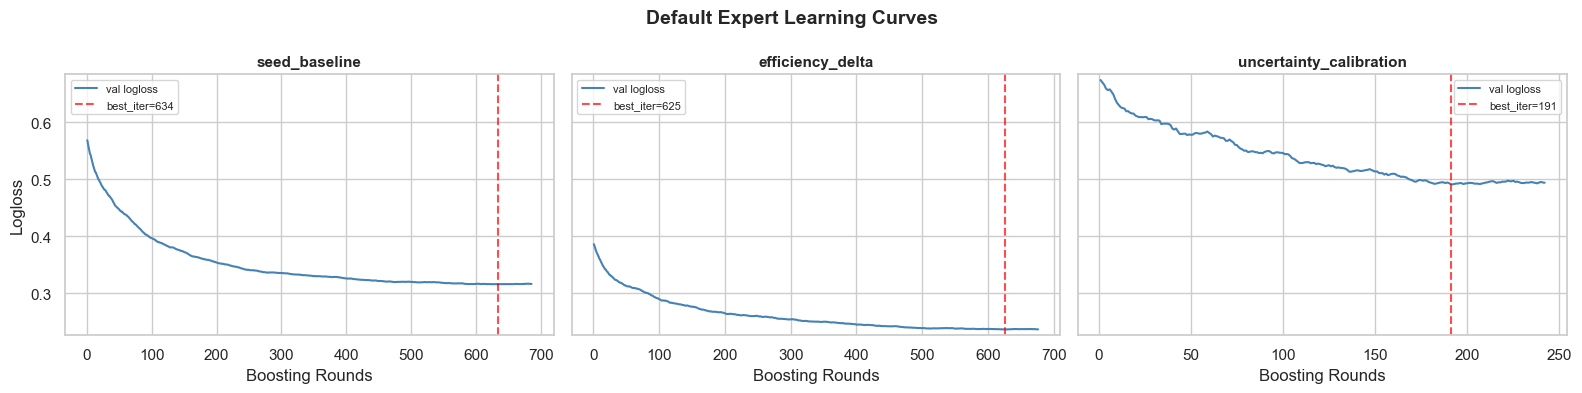

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Determine consistent y-axis range across all experts
all_logloss_vals = []
for etype in EXPERT_TYPES:
    evals = default_experts[etype].model.evals_result()
    all_logloss_vals.extend(evals["validation_0"]["logloss"])
ymin = min(all_logloss_vals) - 0.01
ymax = max(all_logloss_vals) + 0.01

for ax, etype in zip(axes, EXPERT_TYPES):
    evals = default_experts[etype].model.evals_result()
    val_ll = evals["validation_0"]["logloss"]
    epochs = range(1, len(val_ll) + 1)
    ax.plot(epochs, val_ll, label="val logloss", color="steelblue")
    best_iter = default_experts[etype].model.best_iteration
    ax.axvline(x=best_iter, color="red", linestyle="--", alpha=0.7, label=f"best_iter={best_iter}")
    ax.set_title(etype, fontsize=11, fontweight="bold")
    ax.set_xlabel("Boosting Rounds")
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Logloss")
fig.suptitle("Default Expert Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Optuna Per Expert

In [ ]:
studies = {}
best_params = {}

for etype in EXPERT_TYPES:
    def objective(trial, et=etype):
        params = {}
        for k, v in OPTUNA_SEARCH_SPACE.items():
            if k in ("max_depth", "min_child_weight"):
                params[k] = trial.suggest_int(k, int(v[0]), int(v[1]))
            else:
                params[k] = trial.suggest_float(k, v[0], v[1])
        expert = TreeExpert(et, params=params)
        expert.fit(train_fs, val_fs=test_fs)
        preds = expert.predict_proba(test_fs)
        return compute_logloss(test_fs.y.values, preds)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=600)
    studies[etype] = study
    best_params[etype] = study.best_params
    print(f"{etype}: best_logloss={study.best_value:.4f} in {len(study.trials)} trials")

# Display best params table
params_df = pd.DataFrame(best_params).T
params_df.index.name = "expert_type"
print("\nBest Parameters:")
display(params_df.round(4))

## 8. Viz: Optuna History (All 3)

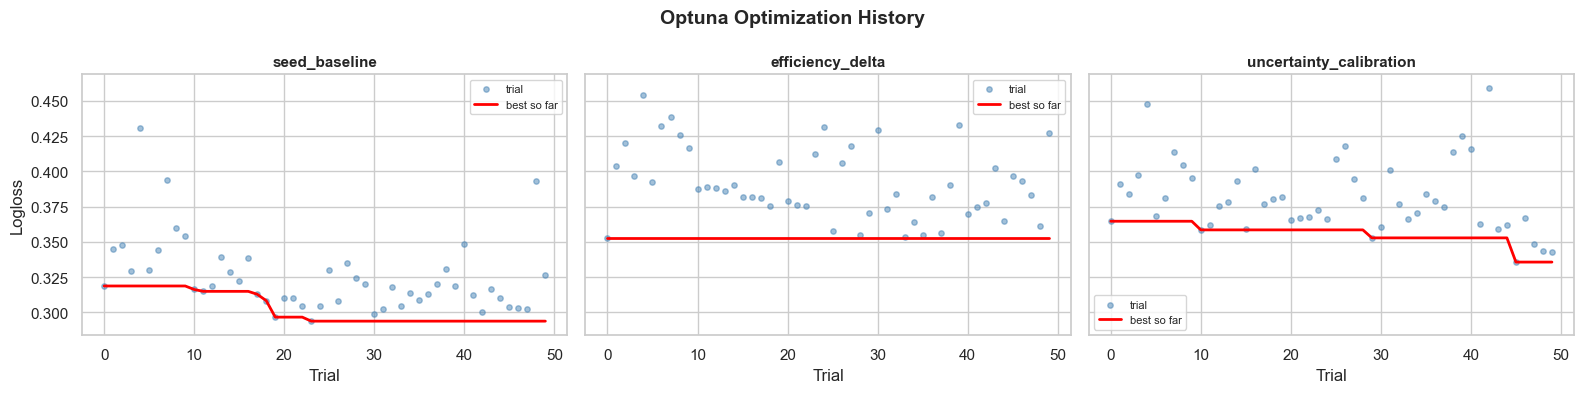

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Determine consistent y-axis range
all_vals = []
for etype in EXPERT_TYPES:
    all_vals.extend([t.value for t in studies[etype].trials if t.value is not None])
ymin_opt = min(all_vals) - 0.01
ymax_opt = max(all_vals) + 0.01

for ax, etype in zip(axes, EXPERT_TYPES):
    study = studies[etype]
    trial_numbers = [t.number for t in study.trials if t.value is not None]
    trial_values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(trial_values)

    ax.scatter(trial_numbers, trial_values, alpha=0.5, s=15, c="steelblue", label="trial")
    ax.plot(trial_numbers, best_so_far, color="red", linewidth=2, label="best so far")
    ax.set_title(etype, fontsize=11, fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylim(ymin_opt, ymax_opt)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Logloss")
fig.suptitle("Optuna Optimization History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Viz: Parameter Importance Comparison

In [ ]:
try:
    from src.models.multi_task_experts import MultiTaskExpertsTrainer

    input_dim = train_fs.X.shape[1]
    # Note: torchsort ranking loss is O(n^2) per head per epoch — keep epochs low
    trainer = MultiTaskExpertsTrainer(input_dim=input_dim, lr=1e-3, epochs=50, ranking_lambda=0.3)
    mt_model = trainer.fit(train_fs, val_fs=test_fs, patience=15)

    # Get per-head predictions: (n, 3)
    mt_preds = mt_model.predict_proba(test_fs.X)
    print(f"Multi-task model predictions shape: {mt_preds.shape}")

    # Compare logloss per head vs XGBoost
    comparison_rows_mt = []
    for i, etype in enumerate(EXPERT_TYPES):
        xgb_ll = tuned_metrics[etype]["logloss"]
        mt_ll = compute_logloss(test_fs.y.values, mt_preds[:, i])
        comparison_rows_mt.append({
            "expert_type": etype,
            "xgb_logloss": xgb_ll,
            "neural_logloss": mt_ll,
            "delta": mt_ll - xgb_ll,
        })

    mt_comparison_df = pd.DataFrame(comparison_rows_mt).set_index("expert_type")
    print("\nXGBoost vs Multi-Task Neural Experts:")
    display(mt_comparison_df.round(4))

    # Correlation between neural heads
    mt_agreement = compute_expert_agreement(mt_preds)
    mt_agreement.index = EXPERT_TYPES
    mt_agreement.columns = EXPERT_TYPES

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        agreement_df, annot=True, fmt=".3f", cmap="RdYlBu_r",
        vmin=0.5, vmax=1.0, ax=axes[0], square=True,
        linewidths=0.5, linecolor="white",
    )
    axes[0].set_title("XGBoost Experts", fontsize=12, fontweight="bold")

    sns.heatmap(
        mt_agreement, annot=True, fmt=".3f", cmap="RdYlBu_r",
        vmin=0.5, vmax=1.0, ax=axes[1], square=True,
        linewidths=0.5, linecolor="white",
    )
    axes[1].set_title("Neural Multi-Task Heads", fontsize=12, fontweight="bold")

    fig.suptitle("Expert Diversity: XGBoost vs Neural", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

except ImportError as e:
    print(f"Skipping Multi-Task Neural Experts: {e}")
    print("Install torchsort to enable this section: pip install torchsort")
except Exception as e:
    print(f"Multi-Task Neural Experts failed: {e}")
    import traceback
    traceback.print_exc()

## 10. Retrain Tuned + Compare

In [ ]:
tuned_experts = {}
tuned_metrics = {}

for etype in EXPERT_TYPES:
    expert = TreeExpert(etype, params=best_params[etype])
    expert.fit(train_fs, val_fs=test_fs)
    tuned_experts[etype] = expert

    preds = expert.predict_proba(test_fs)
    metrics = compute_all_metrics(test_fs.y.values, preds, rounds=test_fs.meta["round"].values)
    tuned_metrics[etype] = metrics

# Comparison table
comparison_rows = []
for etype in EXPERT_TYPES:
    comparison_rows.append({
        "expert_type": etype,
        "default_logloss": default_metrics[etype]["logloss"],
        "tuned_logloss": tuned_metrics[etype]["logloss"],
        "logloss_delta": tuned_metrics[etype]["logloss"] - default_metrics[etype]["logloss"],
        "default_acc": default_metrics[etype]["accuracy"],
        "tuned_acc": tuned_metrics[etype]["accuracy"],
        "best_iteration": tuned_experts[etype].model.best_iteration,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("expert_type")
display(comparison_df.round(4))

## 11. Viz: Tuned Learning Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Consistent y-axis
all_vals_lc = []
for etype in EXPERT_TYPES:
    all_vals_lc.extend(default_experts[etype].model.evals_result()["validation_0"]["logloss"])
    all_vals_lc.extend(tuned_experts[etype].model.evals_result()["validation_0"]["logloss"])
ymin_lc = min(all_vals_lc) - 0.01
ymax_lc = max(all_vals_lc) + 0.01

for ax, etype in zip(axes, EXPERT_TYPES):
    # Default
    def_evals = default_experts[etype].model.evals_result()["validation_0"]["logloss"]
    ax.plot(range(1, len(def_evals) + 1), def_evals, alpha=0.6, label="default", color="gray")

    # Tuned
    tuned_evals = tuned_experts[etype].model.evals_result()["validation_0"]["logloss"]
    ax.plot(range(1, len(tuned_evals) + 1), tuned_evals, label="tuned", color="steelblue")

    best_iter = tuned_experts[etype].model.best_iteration
    ax.axvline(x=best_iter, color="red", linestyle="--", alpha=0.7, label=f"tuned best={best_iter}")

    ax.set_title(etype, fontsize=11, fontweight="bold")
    ax.set_xlabel("Boosting Rounds")
    ax.set_ylim(ymin_lc, ymax_lc)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Logloss")
fig.suptitle("Default vs Tuned Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 12. Expert Diversity: Correlation Matrix

In [ ]:
# Stack tuned expert predictions into (n, 3)
expert_preds_array = np.column_stack([
    tuned_experts[etype].predict_proba(test_fs) for etype in EXPERT_TYPES
])

agreement_df = compute_expert_agreement(expert_preds_array)
agreement_df.index = EXPERT_TYPES
agreement_df.columns = EXPERT_TYPES

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    agreement_df, annot=True, fmt=".3f", cmap="RdYlBu_r",
    vmin=0.5, vmax=1.0, ax=ax, square=True,
    linewidths=0.5, linecolor="white",
)
ax.set_title("Expert Pairwise Spearman Correlation (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Agreement matrix:")
display(agreement_df.round(4))

## 13. Viz: Expert Prediction Scatter Grid

In [ ]:
pred_df = pd.DataFrame(expert_preds_array, columns=EXPERT_TYPES)
pred_df["y_true"] = test_fs.y.values

pairs = [
    ("seed_baseline", "efficiency_delta"),
    ("seed_baseline", "uncertainty_calibration"),
    ("efficiency_delta", "uncertainty_calibration"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (e1, e2) in zip(axes, pairs):
    colors = pred_df["y_true"].map({1: "forestgreen", 0: "tomato"})
    ax.scatter(pred_df[e1], pred_df[e2], c=colors, alpha=0.5, s=20, edgecolors="none")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel(e1, fontsize=10)
    ax.set_ylabel(e2, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(f"{e1}\nvs {e2}", fontsize=10, fontweight="bold")

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="forestgreen", markersize=8, label="higher seed won (y=1)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato", markersize=8, label="upset (y=0)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Expert Prediction Scatter Grid (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Viz: Expert Disagreement

In [ ]:
# Compute max pairwise |pred diff| per game
n_games = expert_preds_array.shape[0]
max_disagreement = np.zeros(n_games)
for i in range(3):
    for j in range(i + 1, 3):
        diff = np.abs(expert_preds_array[:, i] - expert_preds_array[:, j])
        max_disagreement = np.maximum(max_disagreement, diff)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(max_disagreement, bins=40, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(x=np.median(max_disagreement), color="red", linestyle="--", label=f"median={np.median(max_disagreement):.3f}")
ax.set_xlabel("Max Pairwise |Prediction Difference|")
ax.set_ylabel("Count")
ax.set_title("Expert Disagreement Distribution (Test Set)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 most-disagreed games
disagree_df = test_fs.meta.copy()
disagree_df["max_disagreement"] = max_disagreement
for i, etype in enumerate(EXPERT_TYPES):
    disagree_df[f"pred_{etype}"] = expert_preds_array[:, i]
disagree_df["y_true"] = test_fs.y.values

top10 = disagree_df.nlargest(10, "max_disagreement")
display_cols = ["season", "round", "seed_a", "seed_b", "team_name_a", "team_name_b", "y_true", "max_disagreement"]
display_cols += [f"pred_{etype}" for etype in EXPERT_TYPES]
available_cols = [c for c in display_cols if c in top10.columns]
print("\nTop 10 Most-Disagreed Games:")
display(top10[available_cols].round(3))

## 15. Viz: Feature Importance Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

top_n = 15
all_top_features = {}

for ax, etype in zip(axes, EXPERT_TYPES):
    imp = tuned_experts[etype].get_feature_importance()
    top_imp = imp.head(top_n).sort_values(ascending=True)
    all_top_features[etype] = set(top_imp.index)

    # Highlight features unique to this expert
    other_features = set()
    for other_etype in EXPERT_TYPES:
        if other_etype != etype:
            other_imp = tuned_experts[other_etype].get_feature_importance()
            other_features.update(other_imp.head(top_n).index)

    colors = ["darkorange" if f not in other_features else "steelblue" for f in top_imp.index]
    top_imp.plot.barh(ax=ax, color=colors)
    ax.set_title(etype, fontsize=11, fontweight="bold")
    ax.set_xlabel("Gain")

# Add legend for highlighting
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="shared top feature"),
    Patch(facecolor="darkorange", label="unique to this expert"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Top {top_n} Feature Importances by Expert (Gain)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 16. Viz: SHAP Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, etype in zip(axes, EXPERT_TYPES):
    expert = tuned_experts[etype]
    # Use the subsetted features for SHAP (must match what the model was trained on)
    X_shap = expert._prepare_X(test_fs.X, test_fs.ranking_targets)
    explainer = shap.TreeExplainer(expert.model)
    shap_values = explainer.shap_values(X_shap)
    plt.sca(ax)
    shap.summary_plot(
        shap_values, X_shap,
        max_display=12,
        show=False,
        plot_size=None,
    )
    ax.set_title(etype, fontsize=11, fontweight="bold")

fig.suptitle("SHAP Summary Plots by Expert", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 17. Viz: Per-Round Logloss by Expert

In [ ]:
# Compute per-round metrics for each expert
round_data = []
for etype in EXPERT_TYPES:
    preds = tuned_experts[etype].predict_proba(test_fs)
    rbd = compute_round_breakdown(test_fs.y.values, preds, test_fs.meta["round"].values)
    rbd["expert"] = etype
    round_data.append(rbd)

round_df = pd.concat(round_data, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logloss by round
ax = axes[0]
pivot_ll = round_df.pivot(index="round", columns="expert", values="logloss")
pivot_ll[EXPERT_TYPES].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("Round")
ax.set_ylabel("Logloss")
ax.set_title("Per-Round Logloss by Expert", fontsize=12, fontweight="bold")
ax.legend(title="Expert", fontsize=8)
ax.tick_params(axis="x", rotation=0)

# Accuracy by round
ax = axes[1]
pivot_acc = round_df.pivot(index="round", columns="expert", values="accuracy")
pivot_acc[EXPERT_TYPES].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("Round")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Round Accuracy by Expert", fontsize=12, fontweight="bold")
ax.legend(title="Expert", fontsize=8)
ax.tick_params(axis="x", rotation=0)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

fig.suptitle("Expert Performance Breakdown by Tournament Round", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nDetailed round breakdown:")
display(round_df.pivot(index="round", columns="expert", values="logloss").round(4))

## 18. (Tier 2) Multi-Task Neural Experts

In [ ]:
try:
    from src.models.multi_task_experts import MultiTaskExpertsTrainer

    input_dim = train_fs.X.shape[1]
    trainer = MultiTaskExpertsTrainer(input_dim=input_dim, lr=1e-3, epochs=300, ranking_lambda=0.3)
    mt_model = trainer.fit(train_fs, val_fs=test_fs, patience=30)

    # Get per-head predictions: (n, 3)
    mt_preds = mt_model.predict_proba(test_fs.X)
    print(f"Multi-task model predictions shape: {mt_preds.shape}")

    # Compare logloss per head vs XGBoost
    comparison_rows_mt = []
    for i, etype in enumerate(EXPERT_TYPES):
        xgb_ll = tuned_metrics[etype]["logloss"]
        mt_ll = compute_logloss(test_fs.y.values, mt_preds[:, i])
        comparison_rows_mt.append({
            "expert_type": etype,
            "xgb_logloss": xgb_ll,
            "neural_logloss": mt_ll,
            "delta": mt_ll - xgb_ll,
        })

    mt_comparison_df = pd.DataFrame(comparison_rows_mt).set_index("expert_type")
    print("\nXGBoost vs Multi-Task Neural Experts:")
    display(mt_comparison_df.round(4))

    # Correlation between neural heads
    mt_agreement = compute_expert_agreement(mt_preds)
    mt_agreement.index = EXPERT_TYPES
    mt_agreement.columns = EXPERT_TYPES

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        agreement_df, annot=True, fmt=".3f", cmap="RdYlBu_r",
        vmin=0.5, vmax=1.0, ax=axes[0], square=True,
        linewidths=0.5, linecolor="white",
    )
    axes[0].set_title("XGBoost Experts", fontsize=12, fontweight="bold")

    sns.heatmap(
        mt_agreement, annot=True, fmt=".3f", cmap="RdYlBu_r",
        vmin=0.5, vmax=1.0, ax=axes[1], square=True,
        linewidths=0.5, linecolor="white",
    )
    axes[1].set_title("Neural Multi-Task Heads", fontsize=12, fontweight="bold")

    fig.suptitle("Expert Diversity: XGBoost vs Neural", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

except ImportError as e:
    print(f"Skipping Multi-Task Neural Experts: {e}")
    print("Install torchsort to enable this section: pip install torchsort")
except Exception as e:
    print(f"Multi-Task Neural Experts failed: {e}")
    import traceback
    traceback.print_exc()